# 文件: chart_9_1.py

ValueError: 'gris' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

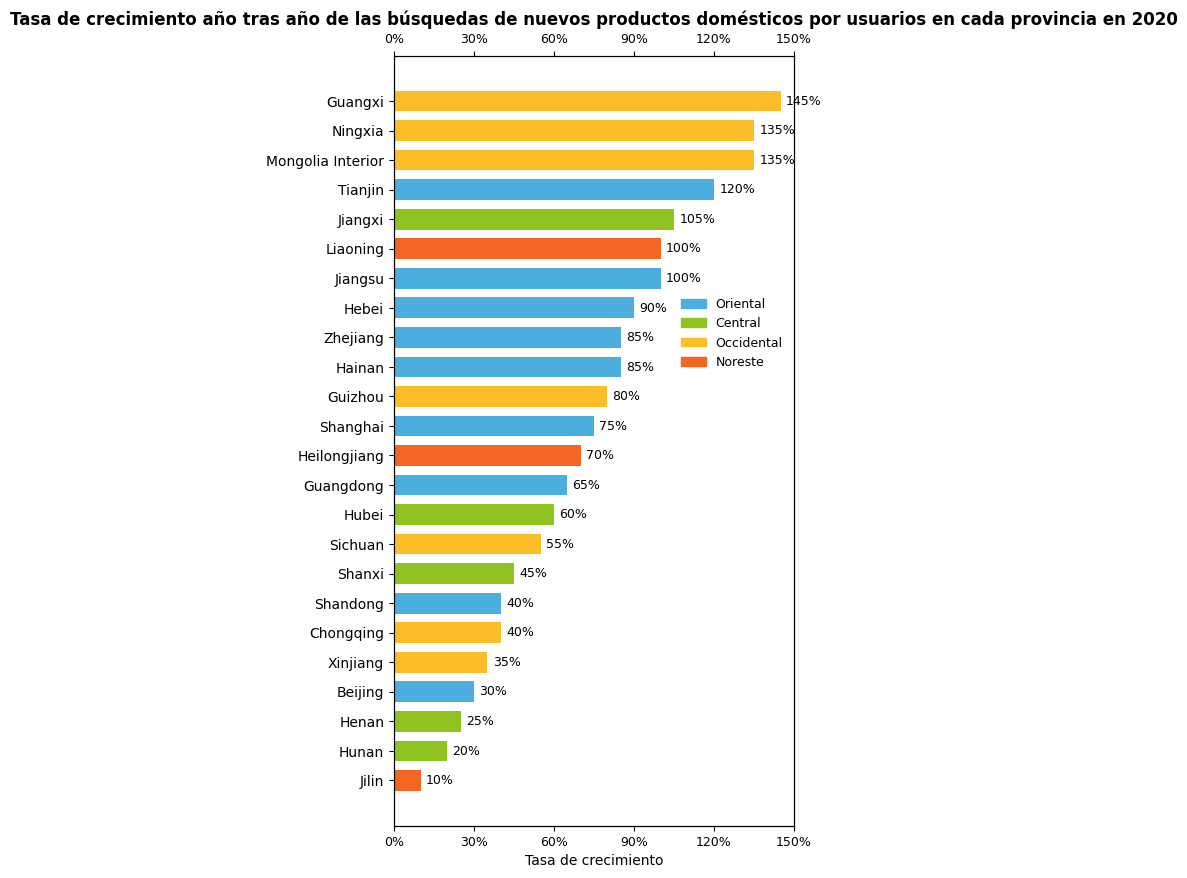

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Definir datos estrictamente según el orden del gráfico (mantener el orden original)
datos = [
    {"provincia": "Guangxi", "region": "Occidental", "crecimiento": 145},
    {"provincia": "Ningxia", "region": "Occidental", "crecimiento": 135},
    {"provincia": "Mongolia Interior", "region": "Occidental", "crecimiento": 135},
    {"provincia": "Tianjin", "region": "Oriental", "crecimiento": 120},
    {"provincia": "Jiangxi", "region": "Central", "crecimiento": 105},
    {"provincia": "Liaoning", "region": "Noreste", "crecimiento": 100},
    {"provincia": "Jiangsu", "region": "Oriental", "crecimiento": 100},
    {"provincia": "Hebei", "region": "Oriental", "crecimiento": 90},
    {"provincia": "Zhejiang", "region": "Oriental", "crecimiento": 85},
    {"provincia": "Hainan", "region": "Oriental", "crecimiento": 85},
    {"provincia": "Guizhou", "region": "Occidental", "crecimiento": 80},
    {"provincia": "Shanghai", "region": "Oriental", "crecimiento": 75},
    {"provincia": "Heilongjiang", "region": "Noreste", "crecimiento": 70},
    {"provincia": "Guangdong", "region": "Oriental", "crecimiento": 65},
    {"provincia": "Hubei", "region": "Central", "crecimiento": 60},
    {"provincia": "Sichuan", "region": "Occidental", "crecimiento": 55},
    {"provincia": "Shanxi", "region": "Central", "crecimiento": 45},
    {"provincia": "Shandong", "region": "Oriental", "crecimiento": 40},
    {"provincia": "Chongqing", "region": "Occidental", "crecimiento": 40},
    {"provincia": "Xinjiang", "region": "Occidental", "crecimiento": 35},
    {"provincia": "Beijing", "region": "Oriental", "crecimiento": 30},
    {"provincia": "Henan", "region": "Central", "crecimiento": 25},
    {"provincia": "Hunan", "region": "Central", "crecimiento": 20},
    {"provincia": "Jilin", "region": "Noreste", "crecimiento": 10}
]

# Extraer datos
provincias = [item["provincia"] for item in datos]
regiones = [item["region"] for item in datos]
crecimientos = [item["crecimiento"] for item in datos]

# Mapeo de región - color (coincidir estrictamente con la imagen original)
color_region = {
    "Oriental": "#4CADDF",  # Azul
    "Central": "#8FC31F",  # Verde
    "Occidental": "#FBBE28",  # Naranja
    "Noreste": "#F26522"  # Rojo
}
colores = [color_region[reg] for reg in regiones]

# Crear un lienzo
plt.figure(figsize=(8, 10))  # Ajustar el tamaño del lienzo para ajustarse a los datos

# Crear el eje x principal (eje x inferior)
ax1 = plt.subplot(111)

# Dibujar un gráfico de barras horizontales (el orden de los datos del eje Y se invierte)
pos_y = np.arange(len(provincias))
barras = ax1.barh(pos_y[::-1], crecimientos, color=colores, height=0.7)

# Establecer las etiquetas del eje Y (nombres de las provincias, mantener el orden original)
ax1.set_yticks(pos_y)
ax1.set_yticklabels(provincias[::-1], fontsize=10)

# Establecer las marcas del eje x inferior (formato de porcentaje)
ax1.set_xlim(0, 150)
ax1.set_xticks([0, 30, 60, 90, 120, 150])
ax1.set_xticklabels(["0%", "30%", "60%", "90%", "120%", "150%"], fontsize=9)
ax1.set_xlabel("Tasa de crecimiento", fontsize=10)

# Crear el eje x superior (compartir el eje Y con el eje x inferior)
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())  # Asegurar que los ejes x superior e inferior tengan el mismo rango
ax2.set_xticks([0, 30, 60, 90, 120, 150])
ax2.set_xticklabels(["0%", "30%", "60%", "90%", "120%", "150%"], fontsize=9)

# Agregar un título
plt.title("Tasa de crecimiento año tras año de las búsquedas de nuevos productos domésticos por usuarios en cada provincia en 2020",
          fontsize=12, fontweight="bold", y=1.03)

# Construir manualmente la leyenda (coincidir con la posición y el estilo original)
from matplotlib.patches import Patch
parches_leyenda = [
    Patch(color=color_region["Oriental"], label="Oriental"),
    Patch(color=color_region["Central"], label="Central"),
    Patch(color=color_region["Occidental"], label="Occidental"),
    Patch(color=color_region["Noreste"], label="Noreste")
]
ax1.legend(handles=parches_leyenda, bbox_to_anchor=(1, 0.7),
           fontsize=9, frameon=False)

# Ajustar el diseño (evitar la superposición de la leyenda y el contenido)
plt.subplots_adjust(left=0.3, right=0.8)  # Reservar espacio a la derecha para la leyenda

# Agregar etiquetas de datos (corregir el orden)
for i, barra in enumerate(barras):
    ancho = barra.get_width()
    ax1.text(ancho + 2, barra.get_y() + barra.get_height() / 2,
             f"{crecimientos[i]}%",  # Corregir el índice, usar directamente i
             ha='left', va='center', fontsize=9)

# Agregar una nota (restaurar estrictamente la nota inferior)
plt.figtext(0.55, 0.05, "Nota: La división regional se refiere a las cuatro principales regiones económicas de China.",
            ha="center", fontsize=8, color="gris")

# Mostrar el gráfico
plt.show()

# 文件: chart_9_2.py

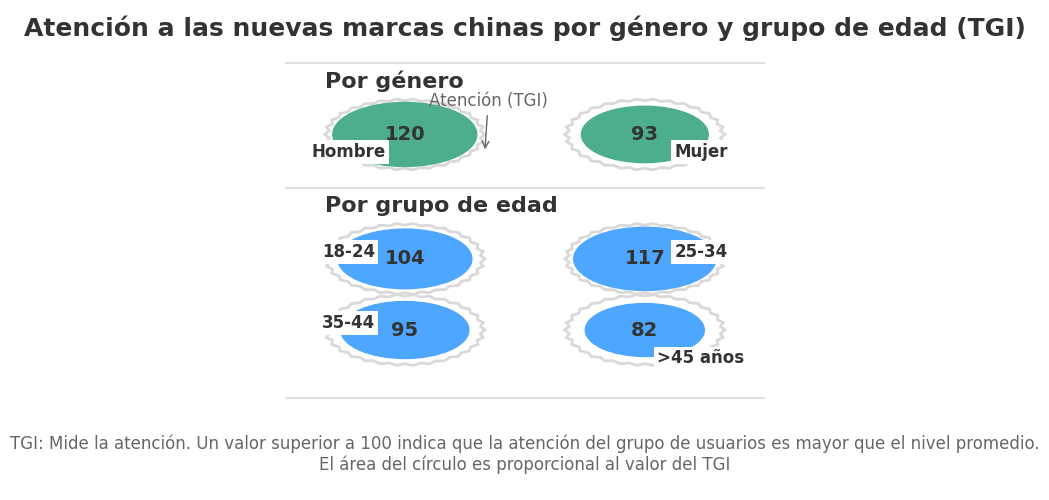

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, PathPatch
from matplotlib.path import Path

# Configuración de datos (combinar grupos de género y edad)
data = {
    "genero": {
        "grupos": ["Hombre", "Mujer"],
        "tgi": [120, 93],
        "color_exterior": "#D9D9D9",  # Color del anillo dentado exterior
        "colores_interiores": ["#4CAD8F", "#4CAD8F"],  # Colores del círculo interior (oscuro para hombres, claro para mujeres)
        "titulo": "Por género",
        "posicion_etiqueta": [(-2.2, 0.5), (2.2, 0.5)],  # Posiciones de las etiquetas (distribuidas a la izquierda y derecha)
        "anotacion": "Atención (TGI)"  # Texto de anotación
    },
    "edad": {
        "grupos": ["18-24", "25-34", "35-44", ">45 años"],
        "tgi": [104, 117, 95, 82],
        "color_exterior": "#D9D9D9",  # Color del anillo dentado exterior
        "colores_interiores": ["#4DA6FF", "#4DA6FF", "#4DA6FF", "#4DA6FF"],  # Azul
        "titulo": "Por grupo de edad",
        "posicion_etiqueta": [(-2.2, 1.2), (2.2, 1.2), (-2.2, -0.8), (2.2, -1.8)],  # Posiciones de las etiquetas
        "anotacion": ""  # No repetir la anotación para los grupos de edad
    }
}

# Crear un lienzo (ajustar la altura para acomodar dos grupos)
fig = plt.figure(figsize=(6, 8), facecolor='white')  # Aumentar la altura del lienzo
ax = fig.add_subplot(111)

# Función principal para dibujar un marco exterior dentado
def dibujar_anillo_dentado(centro, radio, color, num_dientes=30):
    """
    Dibujar un marco exterior fijo con dientes
    :param centro: Coordenadas del centro del círculo (x, y)
    :param radio: Radio del marco exterior
    :param color: Color del marco exterior
    :param num_dientes: Número de dientes (controla la estética)
    """
    theta = np.linspace(0, 2 * np.pi, num_dientes * 2, endpoint=False)
    radios = np.array([radio, radio * 0.95] * num_dientes)
    datos_camino = []
    for t, r in zip(theta, radios):
        x = centro[0] + r * np.cos(t)
        y = centro[1] + r * np.sin(t)
        datos_camino.append((Path.MOVETO if t == 0 else Path.LINETO, (x, y)))
    
    # Cerrar el camino
    datos_camino.append((Path.CLOSEPOLY, (centro[0], centro[1])))
    codigos, vertices = zip(*datos_camino)
    camino = Path(vertices, codigos)
    parche = PathPatch(camino, facecolor='none', edgecolor=color, lw=2)
    ax.add_patch(parche)

# Función para dibujar un círculo interior dinámico
def dibujar_circulo_interior_dinamico(centro, tgi, color, max_tgi=120):
    """
    Dibujar un círculo interior que cambia dinámicamente con el TGI
    :param centro: Coordenadas del centro del círculo (x, y)
    :param tgi: Valor del TGI
    :param color: Color del círculo interior
    :param max_tgi: TGI máximo (utilizado para la normalización)
    """
    # Calcular el radio del círculo interior según la proporción del TGI
    proporcion_radio = np.sqrt(tgi / max_tgi)
    radio_base = 0.9  # Radio base (en relación con el radio del marco exterior de 1.0)
    radio = radio_base * proporcion_radio
    
    circulo_interior = Circle(centro, radio, color=color, zorder=2)
    ax.add_artist(circulo_interior)
    
    # Agregar texto del TGI
    ax.text(
        centro[0], centro[1], 
        f"{tgi}", 
        ha='center', 
        va='center', 
        fontsize=14, 
        fontweight='bold', 
        color='#333333',
        zorder=3
    )

# Función para dibujar una línea separadora
def dibujar_linea_separadora(y_pos, longitud=6, color='#E0E0E0', estilo_linea='-', ancho_linea=1.5):
    """
    Dibujar una línea separadora horizontal
    :param y_pos: Posición de la coordenada Y de la línea separadora
    :param longitud: Longitud de la línea separadora
    :param color: Color de la línea separadora
    :param estilo_linea: Estilo de la línea
    :param ancho_linea: Ancho de la línea
    """
    x_inicio = -longitud / 2
    x_fin = longitud / 2
    ax.plot([x_inicio, x_fin], [y_pos, y_pos], color=color, linestyle=estilo_linea, linewidth=ancho_linea, zorder=1)

# Dibujar todos los grupos
for tipo_grupo, datos_grupo in data.items():
    # Desplazamiento vertical (grupo de género arriba, grupo de edad abajo)
    desplazamiento_y = -3.5 if tipo_grupo == "edad" else 0  # Ajustar el desplazamiento vertical
    
    # Dibujar todos los círculos para cada grupo
    for i, (grupo, tgi, color) in enumerate(zip(
        datos_grupo["grupos"], 
        datos_grupo["tgi"], 
        datos_grupo["colores_interiores"]
    )):
        # Calcular la posición del centro (alternar izquierda y derecha)
        centro = (1.5 if i % 2 == 1 else -1.5, desplazamiento_y + (1.0 if i < 2 else -1.0))
        
        # Dibujar el marco exterior dentado
        dibujar_anillo_dentado(centro, radio=1.0, color=datos_grupo["color_exterior"])
        
        # Dibujar el círculo interior dinámico
        dibujar_circulo_interior_dinamico(centro, tgi, color)
        
        # Agregar etiquetas de grupo
        etiqueta_x, etiqueta_y = datos_grupo["posicion_etiqueta"][i]
        ax.text(
            etiqueta_x, etiqueta_y + desplazamiento_y, 
            grupo, 
            ha='center', 
            va='center', 
            fontsize=12, 
            fontweight='bold', 
            color='#333333',
            bbox=dict(facecolor='white', edgecolor='none', pad=2),
            zorder=4
        )
    
    # Mover el título del grupo hacia arriba
    titulo_y = 2.5 + desplazamiento_y
    ax.text(
        -2.5, titulo_y, 
        datos_grupo["titulo"], 
        ha='left', 
        va='center', 
        fontsize=16, 
        fontweight='bold', 
        color='#333333',
        zorder=5
    )
    
    # Mover la flecha de anotación hacia arriba
    if datos_grupo["anotacion"]:
        ax.annotate(
            datos_grupo["anotacion"], 
            xy=(-0.5, 0.5 + desplazamiento_y), 
            xytext=(-1.2, 1.8 + desplazamiento_y),
            arrowprops=dict(arrowstyle='->', color='#666666'),
            fontsize=12, 
            color='#666666',
            zorder=6
        )

# Agregar el título general
ax.text(
    0, 4.0,  # Mover el título general hacia arriba
    "Atención a las nuevas marcas chinas por género y grupo de edad (TGI)", 
    ha='center', 
    va='center', 
    fontsize=18, 
    fontweight='bold', 
    color='#333333',
    zorder=7
)

# Mover el texto de descripción inferior hacia abajo
ax.text(
    0, -8.0,  # Mover el texto inferior más hacia abajo
    "TGI: Mide la atención. Un valor superior a 100 indica que la atención del grupo de usuarios es mayor que el nivel promedio.\n"
    "El área del círculo es proporcional al valor del TGI", 
    ha='center', 
    va='center', 
    fontsize=12, 
    color='#666666',
    zorder=8
)

# Dibujar tres líneas separadoras
dibujar_linea_separadora(y_pos=3.0)  # Separar el título y el grupo de género
dibujar_linea_separadora(y_pos=-0.5)  # Separar el grupo de género y el grupo de edad
dibujar_linea_separadora(y_pos=-6.4)  # Separar el grupo de edad y la anotación inferior

# Establecer el rango de los ejes
ax.set_xlim(-3, 3)
ax.set_ylim(-9, 4.5)  # Expandir el rango del eje Y para acomodar todo el contenido
ax.axis('off')  # Ocultar los ejes

# Ajustar el diseño
plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.25)
plt.show()

# 文件: chart_9_3.py

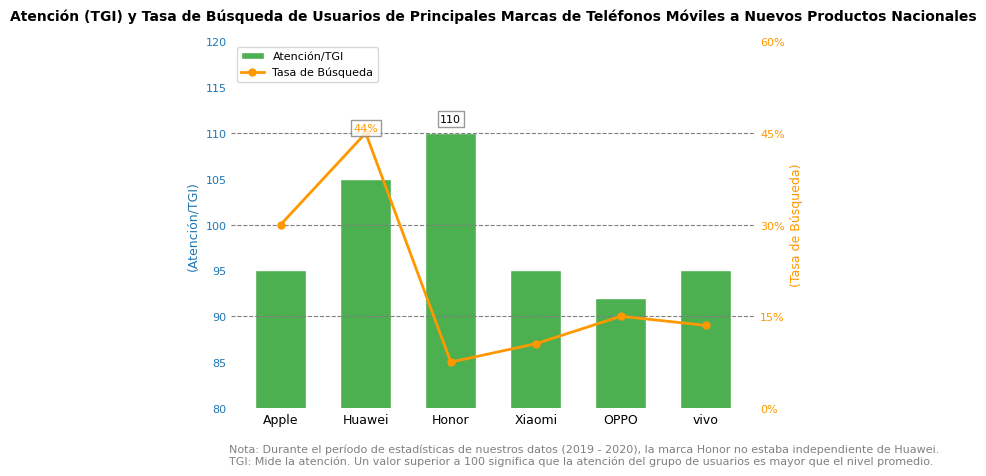

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Definición de datos
marcas = ['Apple', 'Huawei', 'Honor', 'Xiaomi', 'OPPO', 'vivo']
datos_tgi = [95, 105, 110, 95, 92, 95]  # Datos de atención (TGI)
datos_tasa_busqueda_bruta = [100, 110, 85, 87, 90, 89]  # Valores brutos del gráfico de línea de tasa de búsqueda
etiquetas_porcentaje_busqueda = [30, 44, 5, 7, 10, 8]  # Porcentajes reales de búsqueda a etiquetar
destacar_huawei = (1, 44)  # Etiqueta especial para Huawei (índice, valor de etiqueta)
destacar_honor = (2, 110)  # Etiqueta especial para Honor (índice, valor de etiqueta)

# Inicializar el gráfico y el eje doble
fig, ax1 = plt.subplots(figsize=(7, 5), dpi=100)
ax2 = ax1.twinx()

# Dibujar el gráfico de barras (TGI)
x = np.arange(len(marcas))  # Especificar claramente las posiciones de las marcas
grafico_barras = ax1.bar(x, datos_tgi, color='#4CAF50', width=0.6, edgecolor='white')
ax1.set_ylim(80, 120)
ax1.set_ylabel('(Atención/TGI)', color='#1f77b4', fontsize=9)
ax1.tick_params(axis='y', labelcolor='#1f77b4', labelsize=8, length=0)  # Eliminar las líneas de las marcas del eje y
ax1.set_xticks(x)  # Nuevo: Establecer explícitamente las posiciones de las marcas
ax1.set_xticklabels(marcas, fontsize=9)
ax1.tick_params(axis='x', length=0)  # Eliminar las líneas de las marcas del eje x

# Dibujar el gráfico de línea (Tasa de búsqueda)
grafico_linea, = ax2.plot(x, datos_tasa_busqueda_bruta, color='#FF9800', marker='o', markersize=5, linewidth=2)
ax2.set_ylim(80, 120)
ax2.set_ylabel('(Tasa de Búsqueda)', color='#FF9800', fontsize=9)
ax2.tick_params(axis='y', labelcolor='#FF9800', labelsize=8, length=0)  # Eliminar las líneas de las marcas del eje y

# Mapear el eje derecho a porcentajes
def mapear_a_porcentaje(tick):
    return ((tick - 80) / (120 - 80)) * 60

# Personalizar las marcas y etiquetas del eje derecho
ax2.set_yticks([80, 90, 100, 110, 120])
ax2.set_yticklabels([f'{mapear_a_porcentaje(tick):.0f}%' for tick in [80, 90, 100, 110, 120]], fontsize=8)

# Agregar líneas auxiliares discontinuas (referencia al gráfico original)
for y in [90, 100, 110]:
    ax1.axhline(y, color='gray', linestyle='--', linewidth=0.8)

# Etiquetas de datos especiales (Huawei 44%, Honor 110)
# Etiqueta para el punto del gráfico de línea de Huawei
ax2.text(destacar_huawei[0], datos_tasa_busqueda_bruta[destacar_huawei[0]], 
         f'{destacar_huawei[1]}%', 
         ha='center', va='bottom', fontsize=8, color='#FF9800',
         bbox=dict(facecolor='white', edgecolor='gray', pad=2, alpha=0.8))
# Etiqueta para el gráfico de barras de Honor
ax1.text(destacar_honor[0], datos_tgi[destacar_honor[0]] + 1, 
         f'{destacar_honor[1]}', 
         ha='center', va='bottom', fontsize=8, color='black',
         bbox=dict(facecolor='white', edgecolor='gray', pad=2, alpha=0.8))

# Título y anotación
plt.title('Atención (TGI) y Tasa de Búsqueda de Usuarios de Principales Marcas de Teléfonos Móviles a Nuevos Productos Nacionales', fontsize=10, fontweight='bold', pad=15)

texto_anotacion = (
    'Nota: Durante el período de estadísticas de nuestros datos (2019 - 2020), la marca Honor no estaba independiente de Huawei.\n'
    'TGI: Mide la atención. Un valor superior a 100 significa que la atención del grupo de usuarios es mayor que el nivel promedio.'
)
plt.figtext(0.12, 0.01, texto_anotacion, fontsize=8, color='gray', wrap=True)

# Leyenda y optimización del diseño
ax1.legend([grafico_barras, grafico_linea], ['Atención/TGI', 'Tasa de Búsqueda'], 
           loc='upper left', fontsize=8, frameon=True, facecolor='white')
plt.tight_layout(pad=3)

# Eliminar el borde del gráfico
for spine in ax1.spines.values():
    spine.set_visible(False)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.show()

# 文件: chart_9_4.py

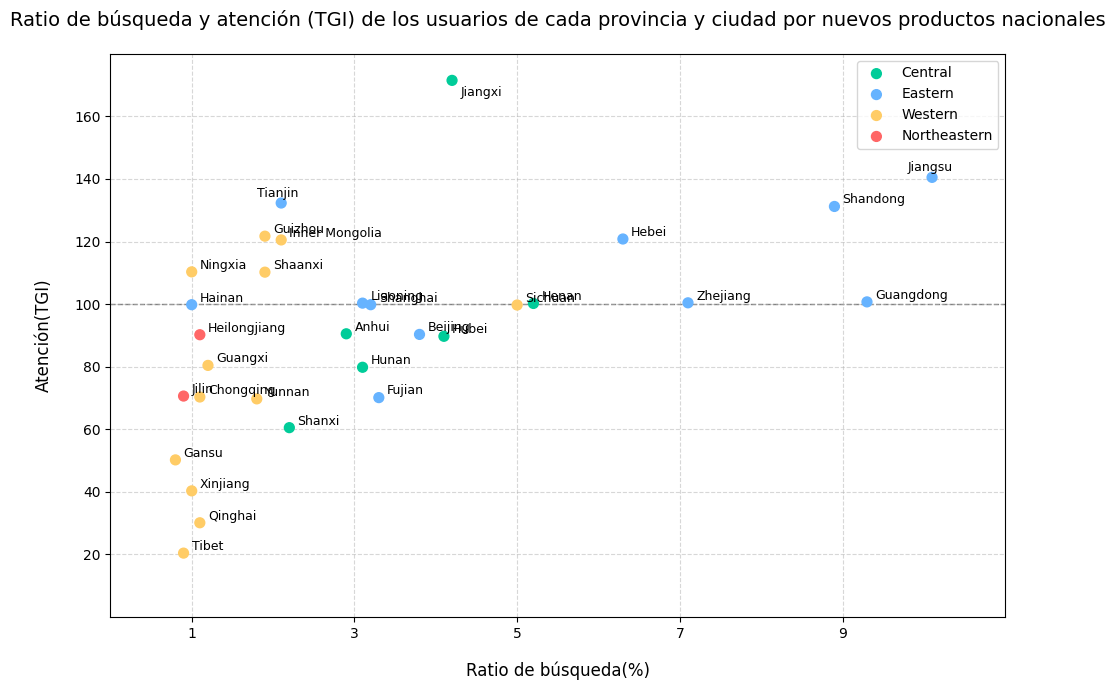

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import random

# Establece la semilla aleatoria para garantizar la reproducibilidad de los resultados
np.random.seed(42)
random.seed(42)

# Extrae con precisión los datos del gráfico, los ajusta a números de punto flotante y agrega un ligero desplazamiento aleatorio
# Formato de datos: Provincia: (Ratio de búsqueda, TGI de atención, Región, Color)
province_data = {
    "Jiangxi": (4.2, 171.5, "Central", "#00cc99"),
    "Tianjin": (2.1, 132.3, "Eastern", "#66b3ff"),
    "Guizhou": (1.9, 121.7, "Western", "#ffcc66"),
    "Hebei": (6.3, 120.8, "Eastern", "#66b3ff"),
    "Shandong": (8.9, 131.2, "Eastern", "#66b3ff"),
    "Jiangsu": (10.1, 140.5, "Eastern", "#66b3ff"),
    "Ningxia": (1.0, 110.3, "Western", "#ffcc66"),
    "Shanghai": (3.2, 99.8, "Eastern", "#66b3ff"),
    "Zhejiang": (7.1, 100.4, "Eastern", "#66b3ff"),
    "Guangdong": (9.3, 100.7, "Eastern", "#66b3ff"),
    "Heilongjiang": (1.1, 90.2, "Northeastern", "#ff6666"),
    "Anhui": (2.9, 90.5, "Central", "#00cc99"),
    "Hubei": (4.1, 89.7, "Central", "#00cc99"),
    "Beijing": (3.8, 90.3, "Eastern", "#66b3ff"),
    "Guangxi": (1.2, 80.4, "Western", "#ffcc66"),
    "Hunan": (3.1, 79.8, "Central", "#00cc99"),
    "Jilin": (0.9, 70.6, "Northeastern", "#ff6666"),
    "Fujian": (3.3, 70.1, "Eastern", "#66b3ff"),
    "Chongqing": (1.1, 70.3, "Western", "#ffcc66"),
    "Yunnan": (1.8, 69.7, "Western", "#ffcc66"),
    "Shanxi": (2.2, 60.5, "Central", "#00cc99"),
    "Gansu": (0.8, 50.2, "Western", "#ffcc66"),
    "Xinjiang": (1.0, 40.3, "Western", "#ffcc66"),
    "Qinghai": (1.1, 30.1, "Western", "#ffcc66"),
    "Tibet": (0.9, 20.4, "Western", "#ffcc66"),
    "Henan": (5.2, 100.2, "Central", "#00cc99"),
    "Hainan": (1.0, 99.8, "Eastern", "#66b3ff"),
    "Liaoning": (3.1, 100.3, "Eastern", "#66b3ff"),
    "Sichuan": (5.0, 99.7, "Western", "#ffcc66"),
    "Inner Mongolia": (2.1, 120.5, "Western", "#ffcc66"),
    "Shaanxi": (1.9, 110.2, "Western", "#ffcc66"),
}

# Agrupa por región
region_dict = defaultdict(list)
for prov, (ratio, tgi, region, color) in province_data.items():
    region_dict[region].append((prov, ratio, tgi, color))

# Crea un lienzo
plt.figure(figsize=(10, 7), facecolor='white')
ax = plt.gca()

# Dibuja un gráfico de dispersión (bucle por región)
for region, prov_list in region_dict.items():
    ratios = [d[1] for d in prov_list]
    tgis = [d[2] for d in prov_list]
    colors = [d[3] for d in prov_list]
    ax.scatter(ratios, tgis, c=colors, label=region, s=50, zorder=2)

    # Agrega etiquetas de texto de las provincias (ajusta finamente la posición para evitar superposiciones)
    for d in prov_list:
        prov, ratio, tgi, _ = d
        # Ajusta manualmente las posiciones de las etiquetas de algunas provincias (ajusta según la visión de la imagen original)
        if prov == 'Jiangxi':
            ax.text(ratio + 0.1, tgi - 5, prov, fontsize=9)
        elif prov in ['Tianjin', 'Jiangsu']:
            ax.text(ratio - 0.3, tgi + 2, prov, fontsize=9)
        else:
            ax.text(ratio + 0.1, tgi + 1, prov, fontsize=9)

# Dibuja una línea de referencia para TGI de atención = 100
ax.axhline(y=100, color='gray', linestyle='--', linewidth=1, zorder=1)

# Establece las etiquetas de los ejes
ax.set_xlabel('Ratio de búsqueda(%)', fontsize=12, labelpad=15)
ax.set_ylabel('Atención(TGI)', fontsize=12, labelpad=15)

# Establece el título
ax.set_title('Ratio de búsqueda y atención (TGI) de los usuarios de cada provincia y ciudad por nuevos productos nacionales', fontsize=14, pad=20)

# Ajusta el rango y las marcas de los ejes
ax.set_xlim(0, 11)
ax.set_ylim(0, 180)
ax.set_xticks([1, 3, 5, 7, 9])  # Coincide estrictamente con las marcas del eje x de la imagen original
ax.set_yticks(range(20, 180, 20))

# Establece la leyenda (alinea la posición con la imagen original)
ax.legend(loc='upper right', bbox_to_anchor=(1, 1), frameon=True, fontsize=10)

# Agrega una cuadrícula
ax.grid(linestyle='--', alpha=0.5, zorder=0)

# Optimiza el diseño
plt.tight_layout()
plt.show()